<a href="https://colab.research.google.com/github/DilemmaFixer3/MZKN_labs/blob/main/lab1_MZKN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завдання №1 (Базовий аналіз та очищення даних)
1. Завантаження та первинний огляд даних

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Завантаження
df = pd.read_csv("stores.csv")

print("=== Розмір таблиці ===")
print(df.shape)  # Очікувано: (80, 15)

print("\n=== Типи стовпців та інформація ===")
print(df.info())

print("\n=== Перші 5 рядків ===")
print(df.head())

print("\n=== Останні 5 рядків ===")
print(df.tail())

=== Розмір таблиці ===
(80, 15)

=== Типи стовпців та інформація ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store_id      80 non-null     object 
 1   region        80 non-null     object 
 2   city          80 non-null     object 
 3   population    80 non-null     float64
 4   format        80 non-null     object 
 5   open_year     80 non-null     int64  
 6   investment    80 non-null     int64  
 7   employees     80 non-null     int64  
 8   area          80 non-null     int64  
 9   rent          80 non-null     float64
 10  revenue       80 non-null     float64
 11  avg_check     77 non-null     float64
 12  profit        80 non-null     float64
 13  online_share  77 non-null     float64
 14  rating        76 non-null     float64
dtypes: float64(7), int64(4), object(4)
memory usage: 9.5+ KB
None

=== Перші 5 рядків ===
  stor

2. Описові статистики та частоти категорій

In [2]:
# Описові статистики для числових колонок
numeric_desc = df.describe().T
print("=== Описові статистики (числові змінні) ===")
print(
    numeric_desc[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ].round(2)
)

# Частоти категоріальних колонок
print("\n=== Частота по областях (region) ===")
print(df["region"].value_counts(dropna=False))

print("\n=== Частота по форматах (format) ===")
print(df["format"].value_counts(dropna=False))

=== Описові статистики (числові змінні) ===
              count     mean     std     min      25%      50%      75%  \
population     80.0    78.75  105.04    13.2    23.80    38.05    71.05   
open_year      80.0  2018.42    4.08  2009.0  2015.00  2019.00  2022.00   
investment     80.0   495.58  165.75   250.0   366.25   448.50   653.50   
employees      80.0     3.68    1.33     2.0     2.75     4.00     5.00   
area           80.0   160.32  109.09     0.0    70.25   150.50   224.25   
rent           80.0   485.22  372.44    43.0   172.50   388.50   736.50   
revenue        80.0  1215.00  408.97   419.0   951.25  1194.00  1439.00   
avg_check      77.0  3435.64  607.20  2227.0  2986.00  3322.00  3787.00   
profit         80.0   129.56   58.25  -180.0   100.00   129.00   161.00   
online_share   77.0    29.64   15.62     3.0    19.20    24.80    39.20   
rating         76.0     4.16    0.40     3.2     3.90     4.20     4.40   

                 max  
population     729.1  
open_year

3. Перевірка наявності пропусків та підозрілих значень
Типові аномалії та пропуски в датасетах роздрібної мережі:

In [3]:
# Перевірка на пропуски (NaN)
print("=== Пропуски по стовпцях ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Перевірка логічних меж значень
print("\n=== Можливі аномалії ===")
print(
    "Рейтинг поза [1, 5]:",
    df[(df["rating"] < 1) | (df["rating"] > 5)][["store_id", "rating"]],
)
print(
    "Від'ємні працівники/площа/оренда:",
    df[(df["employees"] <= 0) | (df["area"] <= 0) | (df["rent"] < 0)][
        ["store_id", "employees", "area", "rent"]
    ],
)
print(
    "Частка онлайн поза [0, 100]:",
    df[(df["online_share"] < 0) | (df["online_share"] > 100)][
        ["store_id", "online_share"]
    ],
)
print(
    "Рік відкриття майбутній:",
    df[df["open_year"] > 2026][["store_id", "open_year"]],
)

=== Пропуски по стовпцях ===
avg_check       3
online_share    3
rating          4
dtype: int64

=== Можливі аномалії ===
Рейтинг поза [1, 5]: Empty DataFrame
Columns: [store_id, rating]
Index: []
Від'ємні працівники/площа/оренда:    store_id  employees  area    rent
41      M42          4     0  1158.0
Частка онлайн поза [0, 100]: Empty DataFrame
Columns: [store_id, online_share]
Index: []
Рік відкриття майбутній:    store_id  open_year
57      M58       2031


In [4]:
import numpy as np
import pandas as pd

# Створюємо копію для очищення
df_clean = df.copy()

# 1. ОБРОБКА АНОМАЛІЙ (РЯДКИ M42 ТА M58)

# 1.1. Магазин M42: площа = 0
# Отримуємо формат магазину M42
m42_format = df_clean.loc[df_clean["store_id"] == "M42", "format"].values[0]

# Варіант А: Заміна на медіанну площу магазинів такого ж формату
median_area = df_clean[
    (df_clean["format"] == m42_format) & (df_clean["area"] > 0)
]["area"].median()
df_clean.loc[df_clean["store_id"] == "M42", "area"] = median_area

# 1.2. Магазин M58: open_year = 2031
# Дивимося на роки відкриття сусідніх магазинів за індексом для контексту:
# print(df_clean.loc[55:60, ['store_id', 'open_year']])
# Замінюємо на медіанний рік відкриття мережі (або опечатка 2013 / 2021)
df_clean.loc[df_clean["store_id"] == "M58", "open_year"] = int(
    df_clean[df_clean["open_year"] <= 2024]["open_year"].median()
)

# 2. ОБРОБКА ПРОПУСКІВ (NaN)

# 2.1. avg_check: заповнюємо медіаною по формату
df_clean["avg_check"] = df_clean["avg_check"].fillna(
    df_clean.groupby("format")["avg_check"].transform("median")
)

# 2.2. online_share: заповнюємо медіаною по формату
df_clean["online_share"] = df_clean["online_share"].fillna(
    df_clean.groupby("format")["online_share"].transform("median")
)

# 2.3. rating: заповнюємо медіаною по всій мережі
df_clean["rating"] = df_clean["rating"].fillna(df_clean["rating"].median())

# 3. ФІНАЛЬНА ПЕРЕВІРКА ПІСЛЯ ОЧИЩЕННЯ

print("Залишок пропусків після очищення:")
print(df_clean[["avg_check", "online_share", "rating", "area"]].isnull().sum())

print("\nПеревірка виправлених магазинів:")
print(
    df_clean[df_clean["store_id"].isin(["M42", "M58"])][
        ["store_id", "format", "area", "rent", "open_year"]
    ]
)

Залишок пропусків після очищення:
avg_check       0
online_share    0
rating          0
area            0
dtype: int64

Перевірка виправлених магазинів:
   store_id  format   area    rent  open_year
41      M42      ТЦ  277.5  1158.0       2020
57      M58  вулиця   89.0   249.0       2019


/tmp/ipykernel_507/3191508635.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '277.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[df_clean["store_id"] == "M42", "area"] = median_area


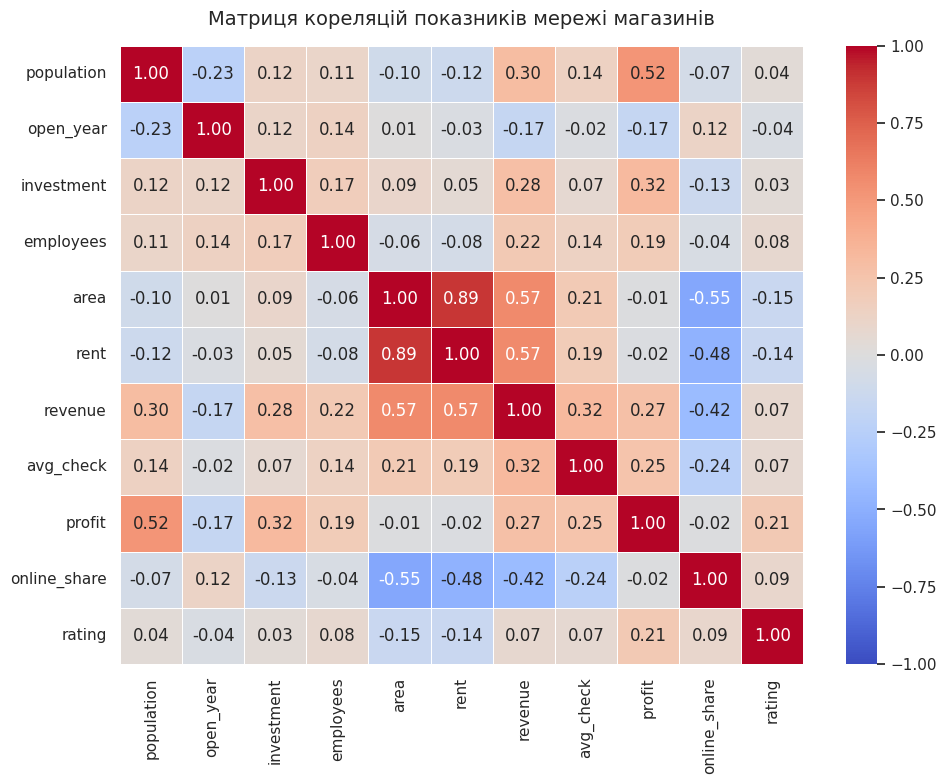

In [5]:
# Вибір числових колонок після очищення
numeric_cols = [
    "population",
    "open_year",
    "investment",
    "employees",
    "area",
    "rent",
    "revenue",
    "avg_check",
    "profit",
    "online_share",
    "rating",
]
corr_matrix = df[numeric_cols].corr()

# Побудова теплової карти
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Матриця кореляцій показників мережі магазинів", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Завдання №2 (Варіант 1)
1. Порівняння сумарного і середнього прибутку по областях

/tmp/ipykernel_507/1773954366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_507/1773954366.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


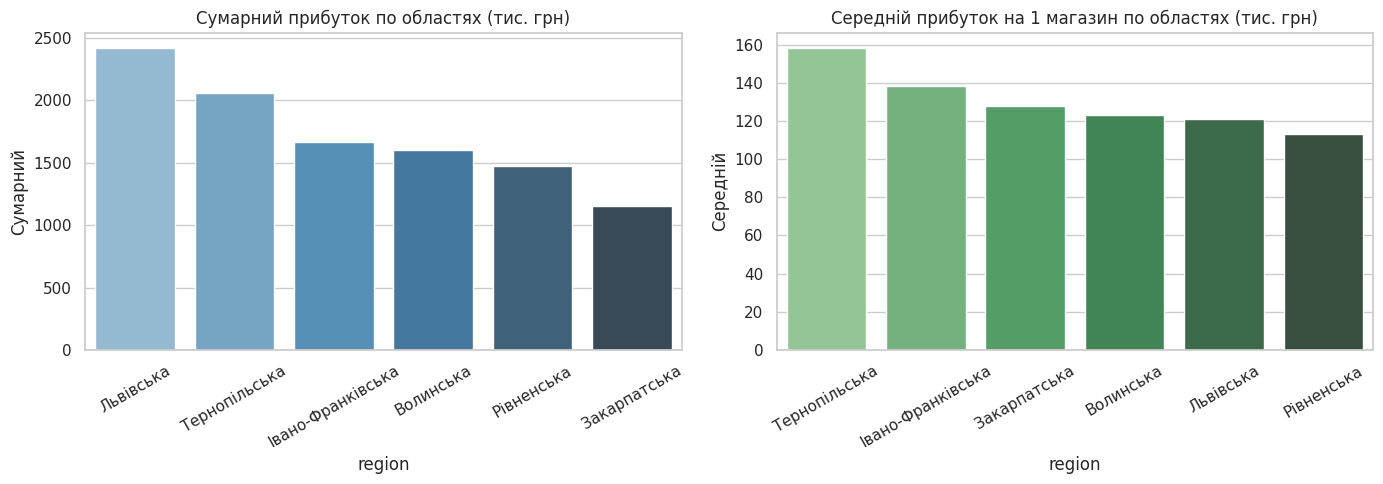

In [6]:
# Агрегація прибутку по областях
region_profit = (
    df.groupby("region")["profit"]
    .agg(Сумарний="sum", Середній="mean")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сумарний прибуток
sns.barplot(
    data=region_profit.sort_values(by="Сумарний", ascending=False),
    x="region",
    y="Сумарний",
    palette="Blues_d",
    ax=axes[0],
)
axes[0].set_title("Сумарний прибуток по областях (тис. грн)")
axes[0].tick_params(axis="x", rotation=30)

# Середній прибуток на магазин
sns.barplot(
    data=region_profit.sort_values(by="Середній", ascending=False),
    x="region",
    y="Середній",
    palette="Greens_d",
    ax=axes[1],
)
axes[1].set_title("Середній прибуток на 1 магазин по областях (тис. грн)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

2. Залежність прибутку від населення міста

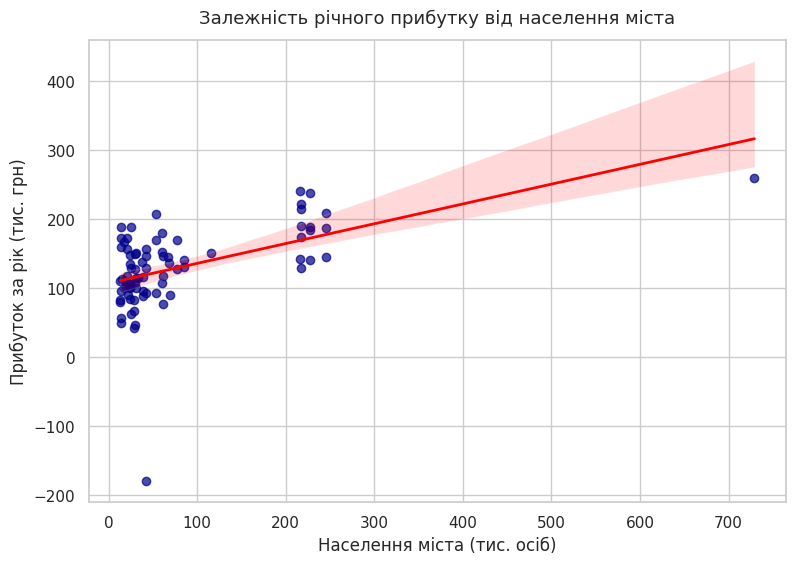

In [7]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df,
    x="population",
    y="profit",
    scatter_kws={"alpha": 0.7, "color": "darkblue"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title(
    "Залежність річного прибутку від населення міста", fontsize=13, pad=12
)
plt.xlabel("Населення міста (тис. осіб)")
plt.ylabel("Прибуток за рік (тис. грн)")
plt.show()

3. Топ-5 найприбутковіших та топ-5 найзбитковіших магазинів

=== ТОП-5 НАЙПРИБУТКОВІШИХ МАГАЗИНІВ ===
store_id             city            region format  profit  revenue  rent  area  avg_check  rating
      M1            Львів         Львівська     ТЦ   260.0   1776.0 358.0 127.0     3424.0     4.4
      M4            Луцьк         Волинська     ТЦ   240.0   1878.0 532.0 214.0     4408.0     4.3
     M40 Івано-Франківськ Івано-Франківська     ТЦ   238.0   1865.0 731.0 179.0     3752.0     3.9
     M21        Тернопіль     Тернопільська     ТЦ   221.0   1983.0 683.0 272.0     5198.0     4.6
     M50        Тернопіль     Тернопільська вулиця   215.0   1337.0 238.0  81.0     4357.0     3.9

=== ТОП-5 НАЙЗБИТКОВІШИХ МАГАЗИНІВ ===
store_id       city     region       format  profit  revenue  rent  area  avg_check  rating
     M64      Вараш Рівненська       вулиця  -180.0   2400.0 184.0  85.0     3042.0     4.1
     M77 Трускавець  Львівська       вулиця    42.0    790.0 324.0 193.0     3872.0     4.7
     M15     Самбір  Львівська       вулиця    46

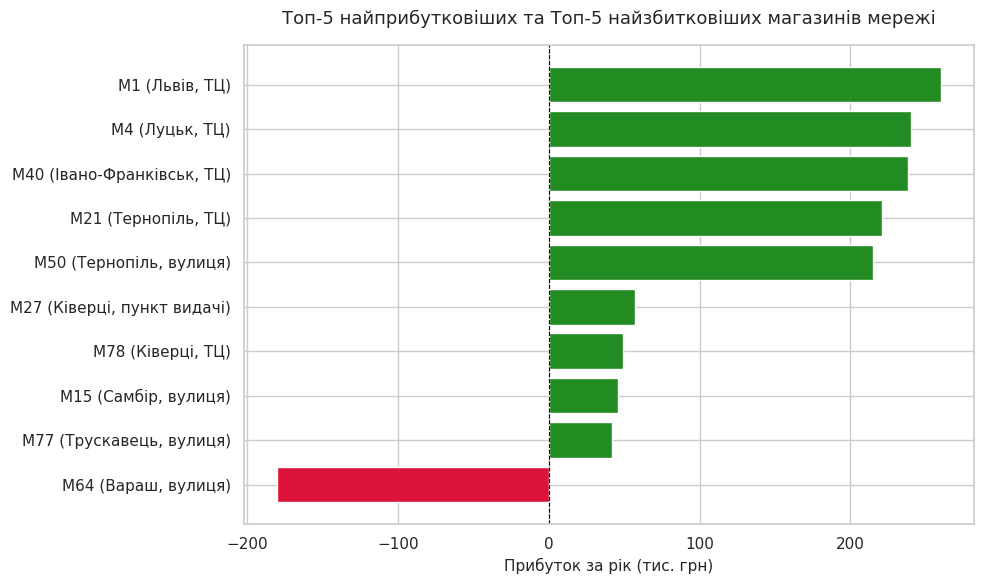

In [10]:
# Ключові колонки для виводу
display_cols = [
    "store_id",
    "city",
    "region",
    "format",
    "profit",
    "revenue",
    "rent",
    "area",
    "avg_check",
    "rating",
]

# Топ-5 найприбутковіших (сортування від найбільшого прибутку до меншого)
top5_stores = df_clean.nlargest(5, "profit")[display_cols]

# Топ-5 найзбитковіших (сортування від найменшого прибутку / найбільшого збитку)
bottom5_stores = df_clean.nsmallest(5, "profit")[display_cols]

print("=== ТОП-5 НАЙПРИБУТКОВІШИХ МАГАЗИНІВ ===")
print(top5_stores.to_string(index=False))

print("\n=== ТОП-5 НАЙЗБИТКОВІШИХ МАГАЗИНІВ ===")
print(bottom5_stores.to_string(index=False))

# Об'єднуємо обидві вибірки
comparison_stores = pd.concat([top5_stores, bottom5_stores]).sort_values(
    "profit"
)

plt.figure(figsize=(10, 6))
colors = [
    "crimson" if p < 0 else "forestgreen" for p in comparison_stores["profit"]
]

bars = plt.barh(
    comparison_stores["store_id"]
    + " ("
    + comparison_stores["city"]
    + ", "
    + comparison_stores["format"]
    + ")",
    comparison_stores["profit"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Прибуток за рік (тис. грн)", fontsize=11)
plt.title(
    "Топ-5 найприбутковіших та Топ-5 найзбитковіших магазинів мережі",
    fontsize=13,
    pad=15,
)
plt.tight_layout()
plt.show()